Задача 1. Аналітика музичного сервісу

Умова

Ви працюєте аналітиком у музичному стрімінговому сервісі. У вас є дані про вподобання користувачів за останній місяць у вигляді ID клієнтів. Маркетинговий відділ хоче зрозуміти перетин аудиторій для планування рекламних кампаній.



Дано три множини користувачів:

rock_fans — слухали рок: {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}

pop_fans — слухали поп: {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}

jazz_fans — слухали джаз: {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}


Використовуючи можливості Python для роботи з множинами (set), напишіть програму та виконайте наступні кроки:

Визначте загальне охоплення: скільки унікальних користувачів слухали хоча б один із цих жанрів?
Знайдіть "всеїдних меломанів" — користувачів, які слухали всі три жанри. Виведіть їхні ID та кількість.
Знайдіть цільову аудиторію для нішевої реклами: "чисті рокери" — ті, хто слухав рок, але НЕ слухав ні поп, ні джаз.
Знайдіть користувачів, які слухали рівно два жанри (будь-яку пару, але не всі три).
Побудуйте візуалізацію перетинів (діаграму Венна) за допомогою бібліотеки matplotlib_venn.

Загальне охоплення: 20
Всеїдні меломани: {105, 115, 110} Кількість: 3
Чисті рокери: {109, 107, 101, 118}
Рівно два жанри: {112, 108, 102, 103}


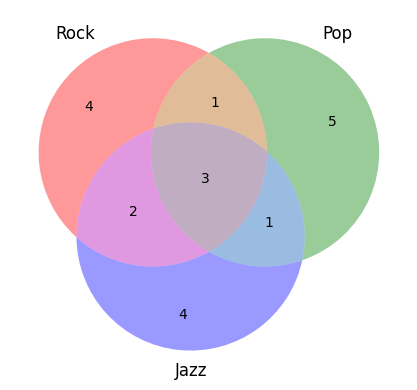

In [5]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3

# множини користувачів
rock_fans = {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}
pop_fans  = {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}
jazz_fans = {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}

# 1. Загальне охоплення
coverage = rock_fans | pop_fans | jazz_fans
print("Загальне охоплення:", len(coverage))

# 2. Всеїдні меломани
melomaniacs = rock_fans & pop_fans & jazz_fans
print("Всеїдні меломани:", melomaniacs, "Кількість:", len(melomaniacs))

# 3. Чисті рокери
pure_rockers = rock_fans - (pop_fans | jazz_fans)
print("Чисті рокери:", pure_rockers)

# 4. Рівно два жанри
two_genres = ((rock_fans & pop_fans) | (rock_fans & jazz_fans) | (pop_fans & jazz_fans)) - melomaniacs
print("Рівно два жанри:", two_genres)

# 5. Діаграма Венна
venn3([rock_fans, pop_fans, jazz_fans], set_labels=('Rock', 'Pop', 'Jazz'))
plt.show()


Задача 2. Конфігуратор доступу до системи

Умова

Ви розробляєте модуль авторизації (RBAC — Role-Based Access Control) для корпоративного порталу. Доступ до різних секцій сайту визначається комбінацією п'яти параметрів користувача. Вам потрібно змоделювати цю логіку та перевірити всі можливі сценарії.



Вхідні параметри користувача (булеві змінні):

is_employee — чи є співробітником компанії

is_verified — чи пройшов верифікацію пошти

is_premium — чи має преміум-підписку

is_admin — чи є адміністратором

is_banned — чи заблокований акаунт


Правила доступу до секцій:

Система має 4 рівні доступу. Доступ надається (True), якщо виконується логічна умова:

Base (Базовий): Користувач є співробітником ТА верифікований ТА НЕ заблокований.

Premium (Преміум): (Користувач є співробітником АБО має преміум) ТА верифікований ТА НЕ заблокований.

Admin (Адмін-панель): Користувач є адміністратором ТА верифікований ТА НЕ заблокований.

Secret (Секретні матеріали): (Користувач є адміністратором АБО (є співробітником ТА має преміум)) ТА верифікований ТА НЕ заблокований.


Напишіть програму на Python, яка виконує наступні кроки:

1. Реалізуйте функцію:

def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
    # Ваш код тут
    pass

Функція повинна повертати словник вигляду {'Base': ..., 'Premium': ..., 'Admin': ..., 'Secret': ...}, де значення — це True або False.

2. Згенеруйте Таблицю істинності для всіх 32 можливих комбінацій параметрів
2 в ступеню 5=32). Підказка: Використовуйте itertools.product([True, False], repeat=5) для генерації вхідних даних.

3. Виведіть таблицю у читабельному форматі (заголовок стовпчиків та рядки значень 0/1). Перші 5 стовпчиків це вхідні параметри користувача, а останні 4 це чи є доступ до відповідного рівня.

Emp   Ver   Prem  Adm   Ban   | Base  Prem  Adm   Secr
-----------------------------------------------------------------
1     1     1     1     1     | 0     0     0     0    
1     1     1     1     0     | 1     1     1     1    
1     1     1     0     1     | 0     0     0     0    
і далі всього 32 рядка

4. Проаналізуйте результати та дайте відповіді на питання (в програмі чи текстом):

У скількох випадках користувач має повний доступ (до всіх 4 секцій одночасно)?
Чи існує комбінація, де користувач має доступ до Premium, але не має доступу до Base? Якщо так, виведіть параметри цієї комбінації та поясніть, чому так сталося.

In [6]:
import itertools

def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
    return {
        "Base":    is_employee and is_verified and not is_banned,
        "Premium": (is_employee or is_premium) and is_verified and not is_banned,
        "Admin":   is_admin and is_verified and not is_banned,
        "Secret":  (is_admin or (is_employee and is_premium)) and is_verified and not is_banned
    }

# Генерація таблиці істинності
print("Emp Ver Prem Adm Ban | Base Prem Adm Secr")
print("-"*50)
full_access_count = 0
premium_without_base = []

for combo in itertools.product([True, False], repeat=5):
    emp, ver, prem, adm, ban = combo
    access = check_access(emp, ver, prem, adm, ban)
    row = [int(emp), int(ver), int(prem), int(adm), int(ban)]
    row_access = [int(access["Base"]), int(access["Premium"]), int(access["Admin"]), int(access["Secret"])]
    print(" ".join(map(str, row)), "|", " ".join(map(str, row_access)))

    if all(row_access):  # повний доступ
        full_access_count += 1
    if access["Premium"] and not access["Base"]:
        premium_without_base.append(combo)

print("\nКількість повних доступів:", full_access_count)
print("Комбінації Premium без Base:", premium_without_base)


Emp Ver Prem Adm Ban | Base Prem Adm Secr
--------------------------------------------------
1 1 1 1 1 | 0 0 0 0
1 1 1 1 0 | 1 1 1 1
1 1 1 0 1 | 0 0 0 0
1 1 1 0 0 | 1 1 0 1
1 1 0 1 1 | 0 0 0 0
1 1 0 1 0 | 1 1 1 1
1 1 0 0 1 | 0 0 0 0
1 1 0 0 0 | 1 1 0 0
1 0 1 1 1 | 0 0 0 0
1 0 1 1 0 | 0 0 0 0
1 0 1 0 1 | 0 0 0 0
1 0 1 0 0 | 0 0 0 0
1 0 0 1 1 | 0 0 0 0
1 0 0 1 0 | 0 0 0 0
1 0 0 0 1 | 0 0 0 0
1 0 0 0 0 | 0 0 0 0
0 1 1 1 1 | 0 0 0 0
0 1 1 1 0 | 0 1 1 1
0 1 1 0 1 | 0 0 0 0
0 1 1 0 0 | 0 1 0 0
0 1 0 1 1 | 0 0 0 0
0 1 0 1 0 | 0 0 1 1
0 1 0 0 1 | 0 0 0 0
0 1 0 0 0 | 0 0 0 0
0 0 1 1 1 | 0 0 0 0
0 0 1 1 0 | 0 0 0 0
0 0 1 0 1 | 0 0 0 0
0 0 1 0 0 | 0 0 0 0
0 0 0 1 1 | 0 0 0 0
0 0 0 1 0 | 0 0 0 0
0 0 0 0 1 | 0 0 0 0
0 0 0 0 0 | 0 0 0 0

Кількість повних доступів: 2
Комбінації Premium без Base: [(False, True, True, True, False), (False, True, True, False, False)]


Задача 3. Формування "Команди мрії"

Умова

Ви — Tech Lead нового амбітного стартапу. Ваше перше завдання — сформувати ідеальну команду для розробки MVP (Minimum Viable Product). HR-відділ надав вам списки кандидатів, які успішно пройшли технічну співбесіду.



У пулі кандидатів є:

Back-end розробники: 8 осіб

Front-end розробники: 6 осіб

UI/UX Дизайнери: 4 особи


Згідно з бюджетом та архітектурою проєкту, команда має складатися рівно з 5 осіб і мати таку структуру:

2 Back-end розробники.

2 Front-end розробники.

1 Дизайнер.


Оскільки всі кандидати у списках кваліфіковані, порядок їх вибору не має значення (команда "Олег і Анна" — це те саме, що "Анна і Олег").



Тобто, це задача на сполучення (combinations). Однак, оскільки ми формуємо одну цілісну команду з різних груп, нам знадобиться правило множення.



Напишіть програму на Python, яка використовує модуль math та виконує наступні кроки:

Обчисліть, скількома способами можна вибрати необхідну кількість Back-end розробників.
Обчисліть, скількома способами можна вибрати необхідну кількість Front-end розробників.
Обчисліть, скількома способами можна вибрати одного дизайнера.
Використовуючи комбінаторне правило множення, знайдіть загальну кількість можливих унікальних складів команди.
Виведіть проміжні результати та фінальну відповідь у зрозумілому форматі.

In [7]:
import math

# кількість способів вибору
back_end = math.comb(8, 2)
front_end = math.comb(6, 2)
designers = math.comb(4, 1)

print(f"Back-end: {back_end}")
print(f"Front-end: {front_end}")
print(f"Designers: {designers}")

total_teams = back_end * front_end * designers
print(f"Загальна кількість команд: {total_teams}")


Back-end: 28
Front-end: 15
Designers: 4
Загальна кількість команд: 1680


Задача 4. Аналіз соціальної мережі компанії

Умова

У невеликій IT-компанії працює 6 людей. HR-відділ хоче проаналізувати комунікацію в корпоративному месенджері: хто з ким спілкується. Вам надали дані про зв'язки між співробітниками.



Співробітники та їхні контакти (неорієнтований граф):

Анна спілкується з: Богдан, Віктор, Ганна

Богдан спілкується з: Анна, Віктор, Дмитро

Віктор спілкується з: Анна, Богдан, Ганна, Дмитро

Ганна спілкується з: Анна, Віктор, Євген

Дмитро спілкується з: Богдан, Віктор, Євген

Євген спілкується з: Ганна, Дмитро


Напишіть програму на Python, яка виконує наступні кроки:

1. Побудуйте три різні представлення цього графа:

Матриця суміжності (як вкладені списки)

Список суміжності (як словник)

Список ребер (як список кортежів)

2. Обчисліть степінь кожної вершини (кількість зв'язків кожного співробітника). Визначте, хто найбільш комунікабельний, а хто — найменш.

3. Перевірте теорему про суму степенів: сума степенів усіх вершин дорівнює подвоєній кількості ребер. Виведіть суму всіх степенів, кількість ребер у графі та підтвердження, що рівність виконується.

In [8]:
# список суміжності
graph = {
    "Анна":   ["Богдан", "Віктор", "Ганна"],
    "Богдан": ["Анна", "Віктор", "Дмитро"],
    "Віктор": ["Анна", "Богдан", "Ганна", "Дмитро"],
    "Ганна":  ["Анна", "Віктор", "Євген"],
    "Дмитро": ["Богдан", "Віктор", "Євген"],
    "Євген":  ["Ганна", "Дмитро"]
}

# список ребер
edges = []
for node, neighbors in graph.items():
    for neighbor in neighbors:
        if (neighbor, node) not in edges:  # уникати дублювання
            edges.append((node, neighbor))

print("Список ребер:", edges)
print("Кількість ребер:", len(edges))

# степені вершин
degrees = {node: len(neighbors) for node, neighbors in graph.items()}
print("Степені вершин:", degrees)

most_social = max(degrees, key=degrees.get)
least_social = min(degrees, key=degrees.get)
print("Найбільш комунікабельний:", most_social, degrees[most_social])
print("Найменш комунікабельний:", least_social, degrees[least_social])

# перевірка теореми про степені
sum_degrees = sum(degrees.values())
print("Сума степенів:", sum_degrees)
print("Подвоєна кількість ребер:", 2*len(edges))
print("Теорема виконується:", sum_degrees == 2*len(edges))


Список ребер: [('Анна', 'Богдан'), ('Анна', 'Віктор'), ('Анна', 'Ганна'), ('Богдан', 'Віктор'), ('Богдан', 'Дмитро'), ('Віктор', 'Ганна'), ('Віктор', 'Дмитро'), ('Ганна', 'Євген'), ('Дмитро', 'Євген')]
Кількість ребер: 9
Степені вершин: {'Анна': 3, 'Богдан': 3, 'Віктор': 4, 'Ганна': 3, 'Дмитро': 3, 'Євген': 2}
Найбільш комунікабельний: Віктор 4
Найменш комунікабельний: Євген 2
Сума степенів: 18
Подвоєна кількість ребер: 18
Теорема виконується: True
